# "You Snooze, You Win" Challenge

Every year, the [PhysioNet/CinC (Computing in Cardiology) Challenge](https://www.physionet.org/challenge/) invites "participants to tackle clinically interesting problems that are either unsolved or not well-solved." For this year's week 2 machine learning challenge, BWSI has revived a past PhysioNet challenge based on sleep classification.

This year's challenge focuses on the classification of nonarousal and arousal timeframes. If you would like to understand the biological implications of the challenge, we recommend reading PhysioNet's [introduction](https://physionet.org/challenge/2018/) of the challenge.

For this challenge, you will classify samples into 5 classes (Arousal, NREM1, NREM2, NREM3, REM). Each sample consists of seven physiological signals (O2-M1, E1-M2, Chin1-Chin2, ABD, CHEST, AIRFLOW, ECG) measured at 200 Hz over a 60 second period (12000 timepoints). In this notebook, we provide code to import the data, visualize sample signals, implement an example classifier, and 'score' your model.

In [2]:
### Import libraries ###

from google.colab import files
import matplotlib.pyplot as plt
import matplotlib

#set default plotting fonts
font = {'family' : 'sans-serif',
        'weight' : 'normal',
        'size'   : 20}

matplotlib.rc('font', **font)

import numpy as np
import os
import pandas as pd
import random
from sklearn import metrics
from sklearn.utils import shuffle
import tensorflow as tf

# added LightGBM (replace Keras)
!pip install -q lightgbm
import lightgbm as lgb

## Loading the Dataset

This dataset is a modified version of the PhysioNet/CinC Challenge data, which were contributed by the Massachusetts General Hospital’s Computational Clinical Neurophysiology Laboratory, and the Clinical Data Animation Laboratory.
***
**Class labels:**
- 0 = Arousal
- 1 = NREM1
- 2 = NREM2
- 3 = NREM3
- 4 = REM
***
**Class descriptions:**

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/sleepStagesTable.svg?raw=true">

***
**Physiological signal description:**

O2-M1 - posterior brain activity (electroencephalography)

E1-M2 - left eye activity (electrooculography)

Chin1-Chin2 - chin movement (electromyography)

ABD - abdominal movement (electromyography)

CHEST - chest movement (electromyography)

AIRFLOW - respiratory airflow

ECG - cardiac activity (electrocardiography)
***
Run both cell blocks to get the challenge data.

In [3]:
# Clone repo and move into data directory (only run this once)
!git clone https://github.com/BeaverWorksMedlytics2020/Data_Public
os.chdir('./Data_Public/ChallengeProjects/Week2/')

Cloning into 'Data_Public'...
remote: Enumerating objects: 5338, done.
remote: Counting objects: 100% (64/64), done.
remote: Compressing objects: 100% (50/50), done.
remote: Total 5338 (delta 28), reused 43 (delta 14), pack-reused 5274 (from 1)
Receiving objects: 100% (5338/5338), 1.11 GiB | 18.20 MiB/s, done.
Resolving deltas: 100% (105/105), done.
Updating files: 100% (5134/5134), done.


## Loading Data in Memory
Run the cell below to extract the raw training and test data. It may take a minute or two to run through. Here are the variables containing the data you will get:

* **data_train**: np array shape (4000, 12000, 7). Contains 4000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **labels_train**: np array shape (4000,). Contains ground truth labels for data_train. The order of the labels corresponds to the order of the training data.
* **ID_train**: list of 4000 unique IDs. The order of the IDs corresponds to the order of the training data.
* **data_test**: np array shape (1000, 12000, 7). Contains 1000 samples (60s each) of 12000 data points (200Hz x 60s), for 7 different signals.
* **ID_test**: list of 1000 unique IDs. The order of the IDs corresponds to the order of the training data.

We encourage you to print each of these variables to see what they look like.

In [4]:
### Run once to import data ###

def get_file_locs():
    '''
    find all files in 'training' and 'test' directories and put their names
    under 'training' and 'test' keys in the file_dict dictionary
    '''

    file_dict = {'training':[], 'test':[]}
    for data_type in file_dict:
        for file in os.listdir('./' + data_type):
            file_dict[data_type].append(data_type + '/' + file)

    return file_dict

def get_sample_data(data_type, id_number):
    '''
    get signal data, label, and filename associated with given data type and index num

    parameters:

     data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

     id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    returns:

     sample_data -- dataframe with 1 row and 2 columns-- column "Signal" contains a series object
                    and column "Label" contains numeric label for that sample
    '''
    file = './' + data_type + '/' + str(id_number) + '.xz'

    #sample_data is a dataframe with 1 row and 2 columns--
    #"Signal" (contains a series object) and "Label" (contains numeric label)
    sample_data = pd.read_pickle('./' + file)

    return sample_data, file.split('/')[2]

file_dict = get_file_locs()
print(f"{len(file_dict['training'])} training samples found, {len(file_dict['test'])} test samples found")

data_train = np.zeros((4000, 12000, 7))
labels_train = np.zeros(4000)
ID_train = []
for i in range(4000):
  sample_data, ID = get_sample_data('training', i)
  # np.float -> np.float32 (depracation)
  data_train[i] = np.array(list(sample_data['Signal']), dtype=np.float32).reshape(12000, 7)
  labels_train[i] = sample_data['Label'].iloc[0]
  ID_train.append(ID)
  if(i%500==0):
    print('Loading training sample ' + str(i))

data_test = np.zeros((1000, 12000, 7))
ID_test = []
for i in range(1000):
  sample_data, ID = get_sample_data('test', i)
  data_test[i] = np.array(list(sample_data['Signal']), dtype=np.float32).reshape(12000, 7)   # np.float -> np.float32 (depracation)
  ID_test.append(ID)
  if(i%500==0):
    print('Loading test sample ' + str(i))

#keep original copy of data_train, labels_train, ID_train, data_test, and ID_test (backup)
data_train_orig = data_train.copy()
labels_train_orig = labels_train.copy()
# defined data_test_orig (not defined prior)
data_test_orig = data_test.copy()
ID_train_orig = ID_train.copy()
data_test_orig = data_test.copy()
ID_test_orig = ID_test.copy()

4000 training samples found, 1000 test samples found
Loading training sample 0
Loading training sample 500
Loading training sample 1000
Loading training sample 1500
Loading training sample 2000
Loading training sample 2500
Loading training sample 3000
Loading training sample 3500
Loading test sample 0
Loading test sample 500


## Data Visualization

Run the cell below to visualize the raw data for a single 60s sample for all 7 signals. We strongly urge you to visualize a few different samples to get a feel for how the data looks and how much each signal can vary in amplitude and frequency from sample to sample. You can change which sample is being visualized by changing the arguments to the graph_signals call.

Training 1593 (NREM1)


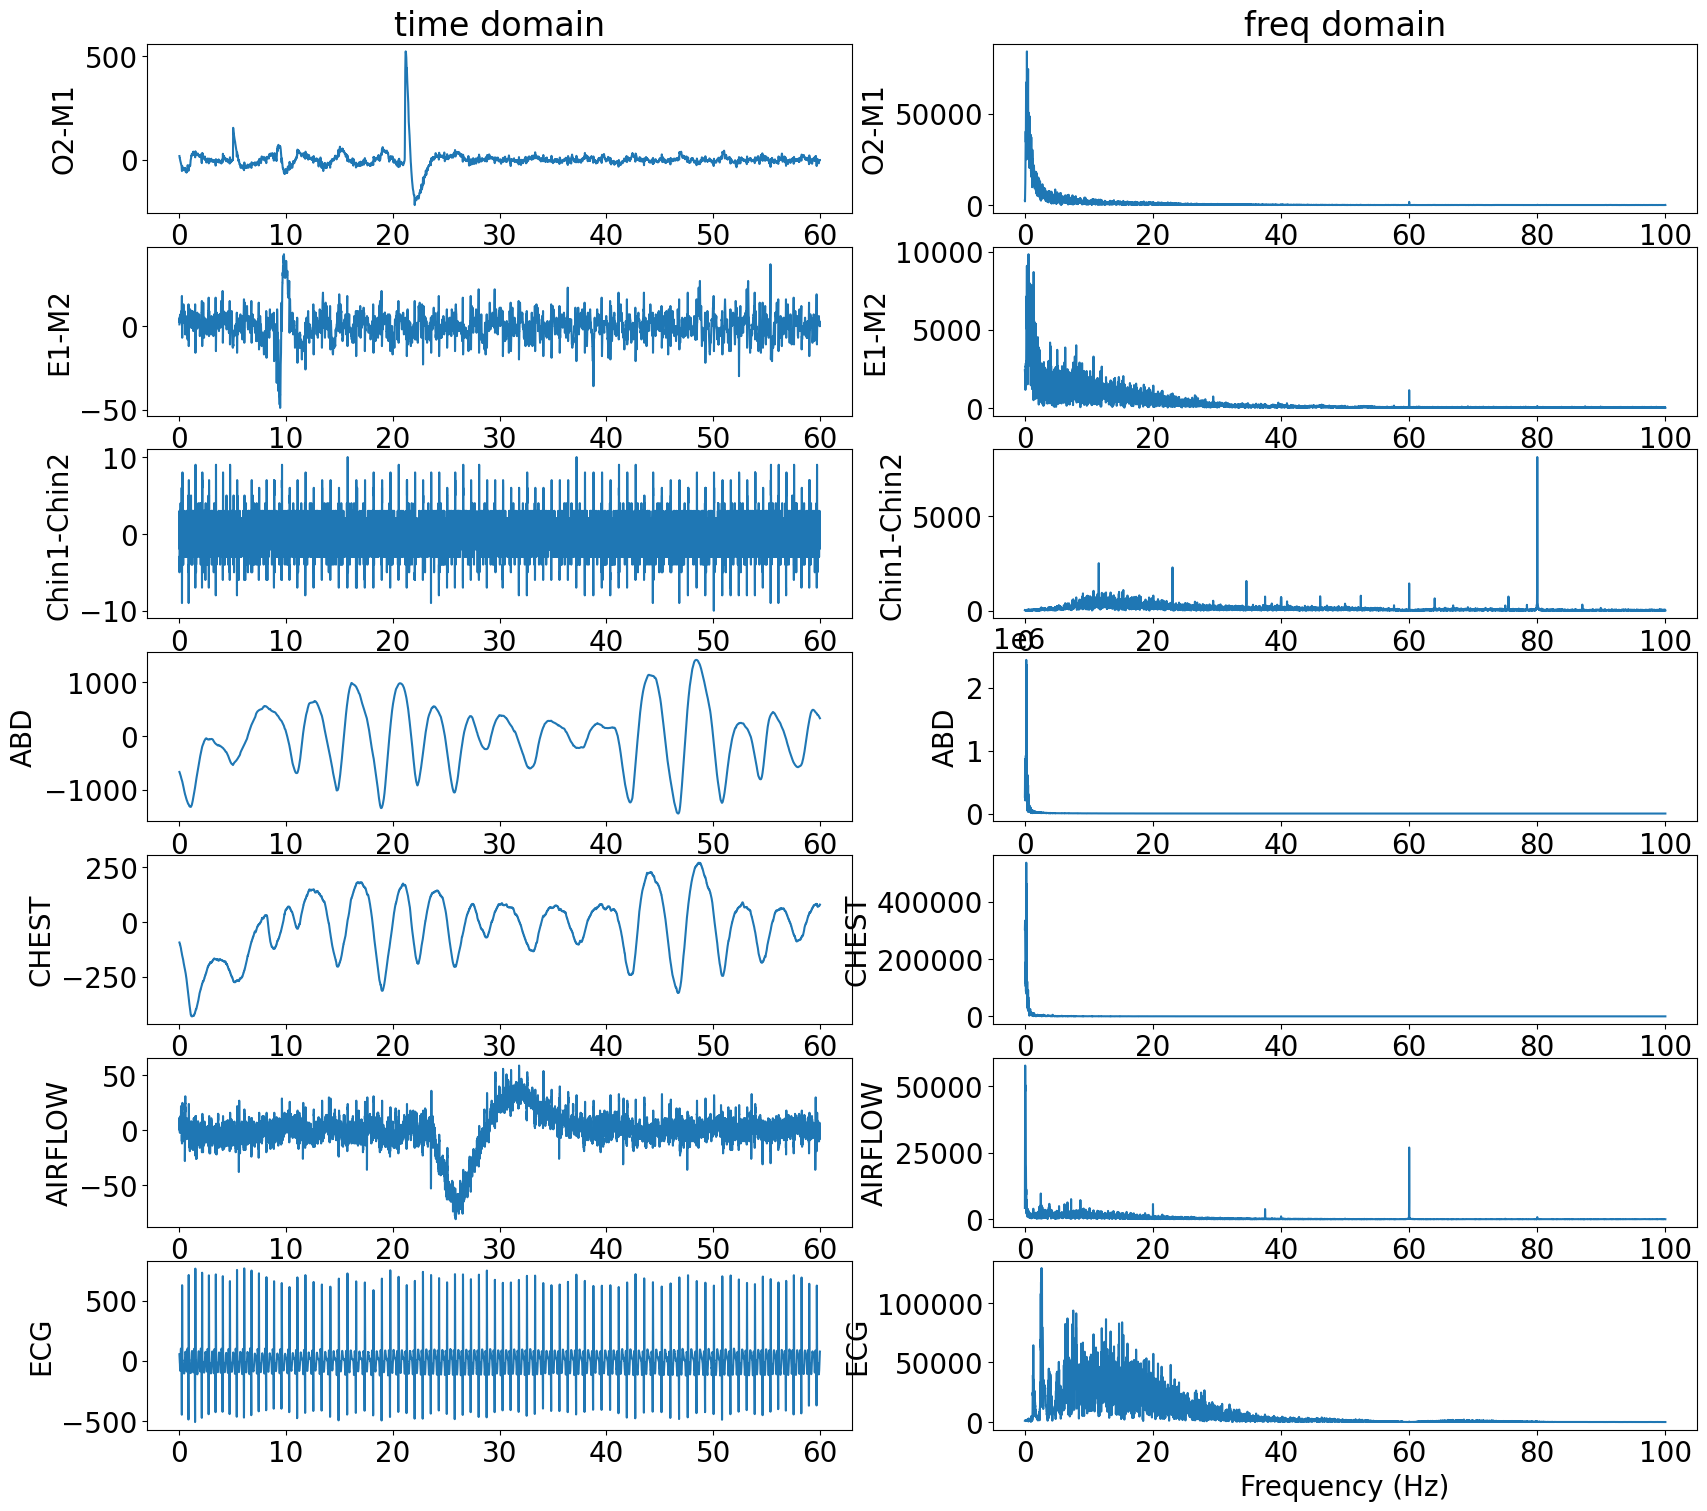

In [5]:
### Define some useful functions to retrieve and plot data from individual samples ###

""" Initalize key reference dictionaries """
sig_dict = {0:'O2-M1', 1:'E1-M2', 2:'Chin1-Chin2', 3:'ABD', 4:'CHEST', 5:'AIRFLOW', 6:'ECG'}
sig_type_dict = {0:'Time (s)', 1:'Frequency (Hz)'}
stage_dict = {0:'Arousal', 1:'NREM1', 2:'NREM2', 3:'NREM3', 4:'REM'}

def graph_signals(data_type = 'training', id_number = None):
    '''
    Create a graph of multiple signals, with rows representing signal class, and
    columns representing signal domain (i.e. time or frequency)

    inputs:

      parameters:

      data_type -- Dictates whether sample comes from training set or test set.
                 This input must be either 'training' or 'test' (defaults to 'training')

      id_number -- Which sample ID should be returned? Must be 0-3999 if data_type is 'training'
                 or 0-999 if data_type is 'test' (defaults to random integer from 0-999)

    '''

    assert data_type in ['test','training'], 'data_type should be either "test" or "training"'

    if id_number is None:
      if data_type == 'training':
        id_number = random.randint(0,3999)
      else:
        id_number = random.randint(0,999)

    #set time_signal_y based on 'test' or 'training' input
    if data_type == 'training':
        time_signal_y = data_train_orig[id_number,:,:]
    else:
        time_signal_y = data_test_orig[id_number,:,:]

    #Get signal values in time domain from either data_train_orig, or data_test_orig
    time_signal_x = np.arange(0, 60, step = 1/200) #this time axis doesn't change

    #Use time-domain signals to get frequency domain signals
    num_datapoints = time_signal_x.shape[0]
    freq_signal_x = np.arange(num_datapoints//2 + 1)/60
    freq_signal_y = np.ndarray(shape = (num_datapoints//2 + 1, 7))
    freq_signal_y = np.abs(np.fft.rfft(time_signal_y, axis = 0))

    plt.figure(figsize = (20, 18))
    title_list = ['time domain', 'freq domain']
    for signal_index in range(7): #7 classes of signal (O2-M1, E2-M2, etc.)
        for signal_domain_index in range(2): #2 types of signal (time and freq domain)
            plt.subplot(7, 2, 2*signal_index + signal_domain_index + 1)
            if signal_index==0:
                plt.title(title_list[signal_domain_index])
            if signal_domain_index == 0: #plot time domain signal
                plt.plot(time_signal_x, time_signal_y[:,signal_index])
            if signal_domain_index == 1: #plot freq domain signal
                plt.plot(freq_signal_x, freq_signal_y[:,signal_index])
            plt.ylabel(sig_dict[signal_index])
        plt.xlabel(sig_type_dict[signal_domain_index])
    plt.show()

# We can now use the above functions to retrieve data for a single sample
# (in the test or training set) and then plot it

#change these 2 lines to plot different samples (note that test set only has 1000 samples)
data_type = 'training'
id_number = random.randint(0,3999)

#print signal ID and the sample label (if known)
if data_type == 'training':
    print(data_type.title(), str(id_number), '(' + stage_dict[id_number//800] + ')')
else:
    print(data_type.title(), str(id_number), '(Unknown)')

#plot data from this sample
graph_signals(data_type = data_type, id_number = id_number)

## Example Classifier

Below is an example of a mediocre classifier for this dataset. It is a simple neural network that uses the spectral flatness of all signal classes its input features--that is, it has 7 input features.

While the example classifier makes use of a neural network, we encourage you to utilize any ML algorithm that you feel would be appropriate.

In [6]:
### Define functions that calculate the features of a single sample ###

import scipy.stats.mstats as mstats
from scipy import signal as sps          # for welch, decimate, hilbert

BANDS = [(0.5,2),(2,4),(4,8),(8,12),(12,16),(16,30),(30,45),(45,70),(70,95)]
BNAME = ['d1','d2','th','al','sg','be','g1','g2','g3']
SIG   = ['O2','EOG','EMG']
FS    = 200.0


def spectral_flatness(fft, zero_thresh = None):
  N = len(fft)
  magnitude = abs(fft[:N//2])* 2 / N

  if(zero_thresh is not None):
      magnitude[magnitude < zero_thresh] = zero_thresh

  sf = mstats.gmean(magnitude) / np.mean(magnitude)

  return sf


def sub_epochs(x, L=1000, H=500):
    #split signal into multiple overlapping segments, helps isolate events. (helper method)
    k = (x.shape[0] - L)//H + 1
    s0, s1 = x.strides
    return np.lib.stride_tricks.as_strided(x, (k, L, x.shape[1]), (s0*H, s0, s1), writeable=False)


def get_features_for_single_sample(data_type = 'training', id_number = None):
    #calculates values for one sample - helper method
    assert data_type in ['test','training'], 'data_type should be either "test" or "training"'

    if id_number is None:
        id_number=random.randint(0,999)

    if data_type == 'training':
        time_signal_y = data_train_orig[id_number,:,:]
    else:
        time_signal_y = data_test_orig[id_number,:,:]

    #---Populate feature vector --
    feature_vector = []

    fft_arr = np.fft.rfft(time_signal_y, axis = 0)
    for ind in range(fft_arr.shape[1]):
        feature_vector.append(spectral_flatness(fft_arr[:,ind], zero_thresh = 10**-10))

    sub = sub_epochs(np.ascontiguousarray(time_signal_y))

    # use sub_epochs helper method, then average results of each segment (welch). less noise
    f, P = sps.welch(sub, fs=FS, nperseg=512, noverlap=256, axis=1)   # P is (23, 257, 7)

    tot_mask = (f>=0.5)&(f<=95)
    total = P[:,tot_mask,:].sum(1) + 1e-12

    def agg3(name, arr):
        feature_vector.extend([arr.mean(), arr.std(), arr.max()])

    for ci, cn in enumerate(SIG):
        agg3(f'{cn}_logtot', np.log10(total[:,ci]))

        rel = []
        for (lo,hi), bn in zip(BANDS, BNAME):
            m = (f>=lo)&(f<hi)
            r = P[:,m,ci].sum(1) / total[:,ci]
            rel.append(r)
            agg3(f'{cn}_rel_{bn}', r)
        rel = np.stack(rel, -1)

        se = -(rel*np.log(rel+1e-12)).sum(-1)/np.log(len(BANDS))
        agg3(f'{cn}_specent', se)

        Pc = P[:,tot_mask,ci]
        cs = np.cumsum(Pc,1)/Pc.sum(1,keepdims=True)
        agg3(f'{cn}_sef95', f[tot_mask][np.clip((cs<0.95).sum(1),0,tot_mask.sum()-1)])

    resp = {}
    #measures breathing rate, rhythm regularity, and raggedness over the full 60 seconds
    for ci, cn in [(3,'ABD'),(4,'CHEST'),(5,'AIR')]:
        # 200 Hz too high for breathing - 'decimate' to 4 Hz
        s = sps.decimate(sps.decimate(time_signal_y[:,ci].astype(np.float64),10,zero_phase=True),5,zero_phase=True)
        s = s - s.mean(); resp[cn] = s

        fr, Pr = sps.welch(s, fs=4.0, nperseg=128, noverlap=96)
        m  = (fr>=0.08)&(fr<=0.7)
        Pb = Pr[m]+1e-12; fb = fr[m]
        feature_vector.append(fb[Pb.argmax()]*60)
        feature_vector.append(Pb.max()/Pb.sum())
        pn = Pb/Pb.sum()
        feature_vector.append(-(pn*np.log(pn)).sum()/np.log(m.sum()))
        feature_vector.append(np.log10(Pb.sum()))
        env = np.abs(sps.hilbert(s))                # steady vs ragged breathing
        feature_vector.append(env.std()/(env.mean()+1e-9))
        lo = Pr[(fr>=0.08)&(fr<0.3)].sum(); hi = Pr[(fr>=0.3)&(fr<1.0)].sum()
        feature_vector.append(hi/(lo+1e-12))

    def cor(a,b):
        a = a-a.mean(); b = b-b.mean()
        return (a*b).sum()/(np.sqrt((a**2).sum()*(b**2).sum())+1e-12)
    feature_vector.append(cor(resp['ABD'],resp['CHEST']))
    feature_vector.append(cor(resp['ABD'],resp['AIR']))
    feature_vector.append(cor(resp['CHEST'],resp['AIR']))

    feature_vector = np.nan_to_num(np.array(feature_vector, dtype=np.float64),
                                   nan=0.0, posinf=0.0, neginf=0.0)

    return feature_vector.reshape(-1, 1)

def get_features(data_type, num_samples):
    #get values/features for each sample

    features, order = np.array([]), np.array([])
    for i in range(num_samples):
        single_sample_features = get_features_for_single_sample(data_type = data_type, id_number = i)
        features = np.hstack((features, single_sample_features)) if features.size else single_sample_features
        order = np.append(order, i).astype(np.float32)
    features = features.astype(np.float32)

    return np.transpose(features), order

In [7]:
### Run every time you modify your feature extraction ###

print('calculating features for training data...')
train_data, train_order = get_features('training', 4000)


print('calculating features for test data...')
test_data, test_order = get_features('test', 1000)

print('done:', train_data.shape, test_data.shape)   # (4000, 370) (1000, 370)

calculating features for training data...


/tmp/ipykernel_782/1823223334.py:76: RuntimeWarning: invalid value encountered in divide
  cs = np.cumsum(Pc,1)/Pc.sum(1,keepdims=True)


calculating features for test data...
done: (4000, 136) (1000, 136)


## Visualize Entire Dataset's Features

In [8]:
### Create label array for all training samples using categorical datatype ###

train_labels = np.ndarray(shape = (1, 4000))

#set labels to integers first
for i in range(4000):
    train_labels[0][i] = i//800 # This is a way to label each entry (since classes are in order)

#convert labels to onehot, ensure type is float32
train_labels = tf.keras.utils.to_categorical(train_labels[0], 5)
train_labels = train_labels.astype(np.float32)

train_data.shape = (4000, 136) 
 train_labels.shape = (4000, 5)




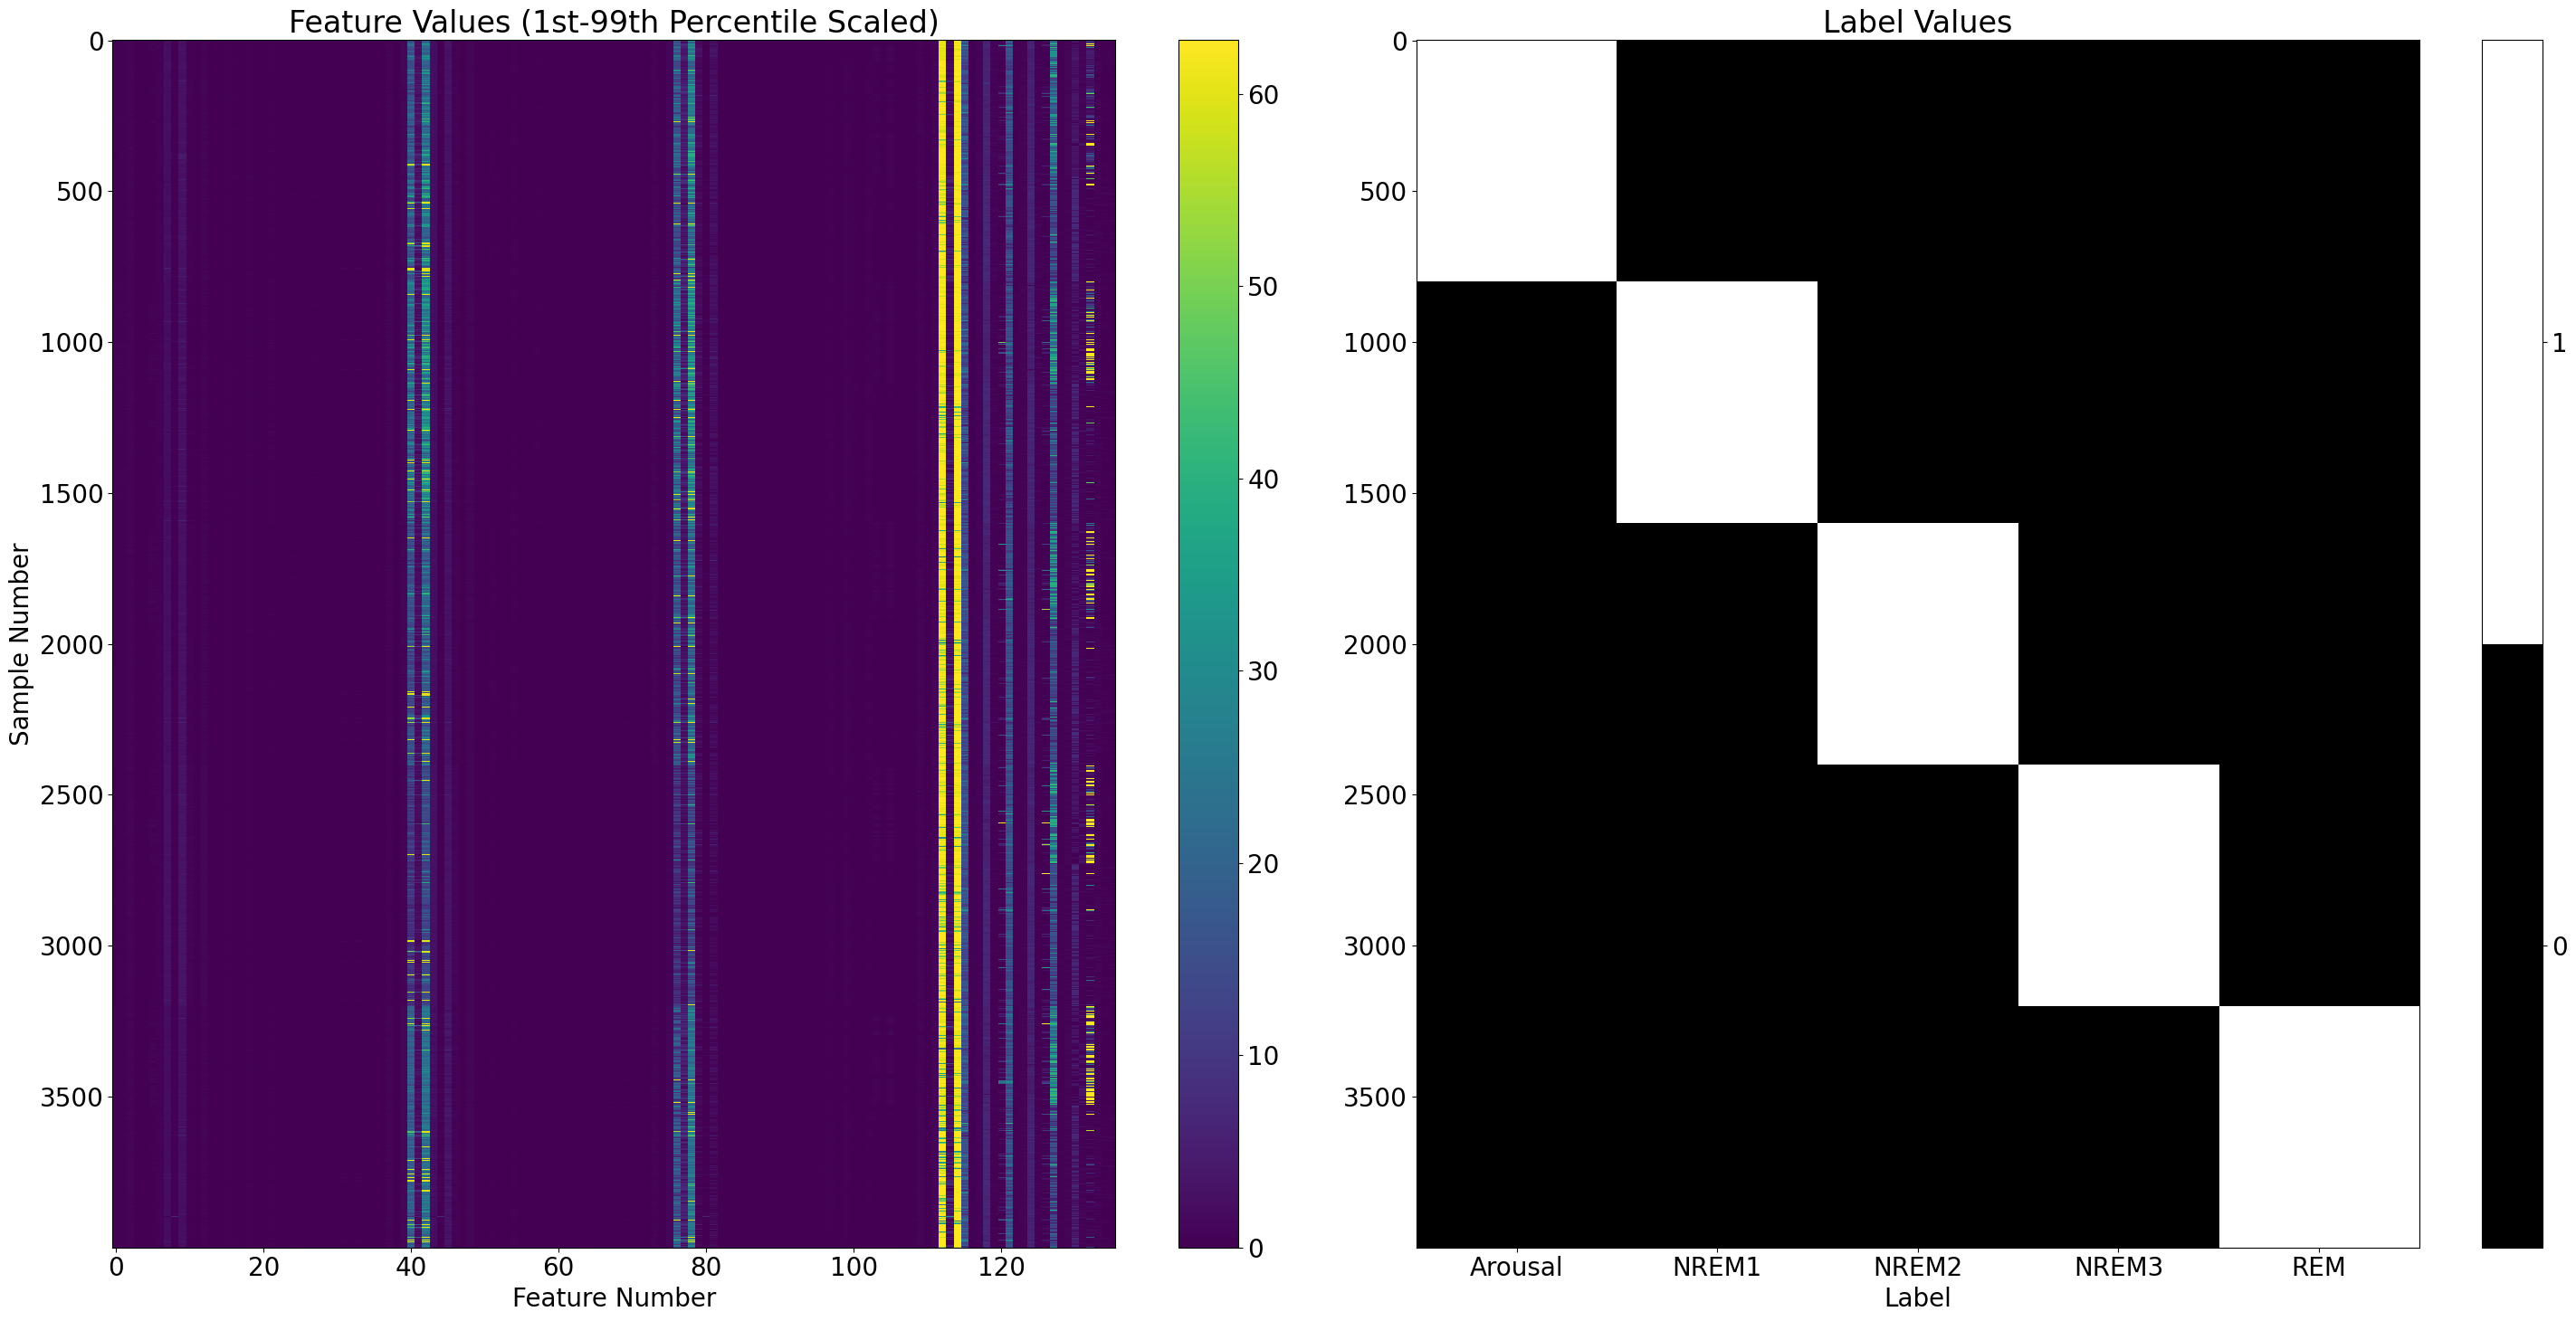

In [22]:
### Run whenever you want to check or view your data and labels ###
print(f"train_data.shape = {train_data.shape} \n train_labels.shape = {train_labels.shape}\n\n")

# Calculate robust min/max using percentiles to prevent outliers from washing out the plot
vmin_val = np.percentile(train_data, 1)
vmax_val = np.percentile(train_data, 99)

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize= (30,15))

# Use vmin and vmax to focus the color scale on the bulk of the data
featureImg = ax1.imshow(train_data, aspect = 'auto', interpolation = 'None', vmin=vmin_val, vmax=vmax_val)
ax1.set_title('Feature Values (1st-99th Percentile Scaled)')
ax1.set_ylabel('Sample Number')
ax1.set_xlabel('Feature Number')
fig.colorbar(featureImg, ax = ax1)

from matplotlib.colors import ListedColormap
bw_cmap = ListedColormap(np.array([[0,0,0,1],[1,1,1,1]]))
labelImg = ax2.imshow(train_labels, aspect = 'auto', cmap = bw_cmap, interpolation = 'None', vmin = 0, vmax = 1.0)
ax2.set_title('Label Values')
ax2.set_xlabel('Label')
ax2.set_xticks(range(len(stage_dict)))
ax2.set_xticklabels([stage_dict[i] for i in range(len(stage_dict))])
fig.colorbar(labelImg, ax = ax2, boundaries = np.linspace(-0.5, 1.5, 3), ticks = [0, 1])

plt.tight_layout()
plt.show()

In [10]:
#### Run every time you modify your feature extraction ###

train_data_shuffled, train_labels_shuffled = shuffle(train_data, train_labels, random_state = 25)

""" val_size (int) must be from 0-4000 """
val_size = 1000
mocktest_size = 500

val_data = train_data_shuffled[:val_size]
mocktest_data = train_data_shuffled[val_size:val_size + mocktest_size]
partial_train_data = train_data_shuffled[val_size + mocktest_size:]

val_labels = train_labels_shuffled[:val_size]
mocktest_labels = train_labels_shuffled[val_size:val_size + mocktest_size]
partial_train_labels = train_labels_shuffled[val_size + mocktest_size:]

print('train/val/mocktest sizes:', partial_train_data.shape[0], val_data.shape[0], mocktest_data.shape[0])

train/val/mocktest sizes: 2500 1000 500


In [11]:
### Run every time you change set of parameters ###

""" Modify to your heart's and algorithm's content ^_^ """

# swapped Keras to LightGBM

params = {
    'objective': 'multiclass',
    'num_class': 5,
    'metric': 'multi_logloss',
    'learning_rate': 0.03,
    'num_leaves': 31,
    'min_data_in_leaf': 40,
    'feature_fraction': 0.2,
    'bagging_fraction': 0.7,
    'bagging_freq': 1,
    'lambda_l2': 10.0,
    'verbose': -1,
    'seed': 0,
}

print(params)

{'objective': 'multiclass', 'num_class': 5, 'metric': 'multi_logloss', 'learning_rate': 0.03, 'num_leaves': 31, 'min_data_in_leaf': 40, 'feature_fraction': 0.2, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'lambda_l2': 10.0, 'verbose': -1, 'seed': 0}


In [12]:
### Run whenever you want to train and validate your model ###

EPOCHS = 2000

training_set   = lgb.Dataset(partial_train_data, label=partial_train_labels.argmax(1))
validation_set = lgb.Dataset(val_data, label=val_labels.argmax(1))

model = lgb.train(params, training_set,
                  num_boost_round=EPOCHS,
                  valid_sets=[training_set, validation_set],
                  valid_names=['train', 'val'],
                  callbacks=[lgb.log_evaluation(50),            # print progress every 50 rounds
                             lgb.early_stopping(50, verbose=True)])

best_iter = model.best_iteration
print('\nBest iteration: %d' % best_iter)
print('Validation accuracy: %.4f'
      % (model.predict(val_data).argmax(1) == val_labels.argmax(1)).mean())

Training until validation scores don't improve for 50 rounds
[50]	train's multi_logloss: 0.771741	val's multi_logloss: 0.904168
[100]	train's multi_logloss: 0.538065	val's multi_logloss: 0.757103
[150]	train's multi_logloss: 0.411938	val's multi_logloss: 0.705814
[200]	train's multi_logloss: 0.323556	val's multi_logloss: 0.681185
[250]	train's multi_logloss: 0.260256	val's multi_logloss: 0.667693
[300]	train's multi_logloss: 0.212642	val's multi_logloss: 0.660444
[350]	train's multi_logloss: 0.176111	val's multi_logloss: 0.657878
[400]	train's multi_logloss: 0.148292	val's multi_logloss: 0.656762
[450]	train's multi_logloss: 0.126328	val's multi_logloss: 0.656845
Early stopping, best iteration is:
[421]	train's multi_logloss: 0.138293	val's multi_logloss: 0.65625

Best iteration: 421
Validation accuracy: 0.7520


In [13]:
### Run once after you have finished training your model ###

final_model = lgb.train(params,
                        lgb.Dataset(train_data, label=train_labels.argmax(1)),
                        num_boost_round=best_iter)

test_pred = final_model.predict(test_data)
test_output = np.ndarray(shape = (1000, 6))

# """ Add column with file number """
for i in range(1000):
    test_output[i] = np.append(test_pred[i], test_order[i])
test_dataframe = pd.DataFrame(test_output)

""" Sort dataframe according to file number """
sorted_test_dataframe = test_dataframe.sort_values(by=[5])

""" Drop file number column """
processed_test_dataframe = sorted_test_dataframe.drop(sorted_test_dataframe.columns[5], axis=1)

print(test_dataframe.head(), '\n\n', sorted_test_dataframe.head(), '\n\n', processed_test_dataframe.head())

assert processed_test_dataframe.shape == (1000, 5), processed_test_dataframe.shape
assert np.allclose(processed_test_dataframe.sum(axis=1), 1), 'rows must be probabilities'
print('\npredicted class counts:', np.bincount(test_pred.argmax(1), minlength=5),
      '  <- expect roughly 200 each if the test set is balanced like the training set')

file = 'SquashisGreatL.xz'      # your team name goes here
processed_test_dataframe.to_pickle(file)
test_dataframe = pd.DataFrame(test_output)
os.listdir('.')
files.download(file)

          0         1         2         3         4    5
0  0.004710  0.001207  0.067353  0.924725  0.002005  0.0
1  0.500195  0.293551  0.171618  0.025230  0.009406  1.0
2  0.025016  0.848212  0.045506  0.000669  0.080598  2.0
3  0.004130  0.007367  0.878016  0.082807  0.027679  3.0
4  0.878588  0.079021  0.026245  0.009813  0.006332  4.0 

           0         1         2         3         4    5
0  0.004710  0.001207  0.067353  0.924725  0.002005  0.0
1  0.500195  0.293551  0.171618  0.025230  0.009406  1.0
2  0.025016  0.848212  0.045506  0.000669  0.080598  2.0
3  0.004130  0.007367  0.878016  0.082807  0.027679  3.0
4  0.878588  0.079021  0.026245  0.009813  0.006332  4.0 

           0         1         2         3         4
0  0.004710  0.001207  0.067353  0.924725  0.002005
1  0.500195  0.293551  0.171618  0.025230  0.009406
2  0.025016  0.848212  0.045506  0.000669  0.080598
3  0.004130  0.007367  0.878016  0.082807  0.027679
4  0.878588  0.079021  0.026245  0.009813  0.00633

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Submitting Your Model

After training your classifier, run it on the test data to generate your predictions. Each class for a test sample should have an associated probability (between 0 and 1). Below are the parameters for the prediction format and export:

- Your predictions should be in a pandas dataframe with 5 columns (classes) and 1000 rows (samples). Note that your predictions must follow the original test sample order (0.xz, 1.xz, 2.xz, ...). You only need to worry about this if you shuffled the test samples or stored the samples in an unordered data structure (dictionaries and sets). If this is the case, you should 1) add a separate column in your pandas dataframe with the file number for each sample; 2) sort the dataframe using this column; and 3) drop the column. These steps have been noted in the code below.
- The predictions dataframe should be exported as an .xz file using dataframe.to_pickle() followed by files.download().

Example code of the prediction format and export is presented in the cell block below.

Your model will be evaluated on Area Under the ROC Curve (ROCAUC), Matthews Correlation Coefficient (MCC) and creativity. There will be a "winning" group for each of these categories.

If you are finished early, consider trying other ML algorithms and/or implementing multiple feature extraction methods. You can also help other groups if you finish early.

## How Your Model Will Be Evaluated

- **Area Under the ROC Curve (AUCROC)**: The receiver operating characteristic (ROC) curve plots the true positive rate (sensitivity/recall) against the false positive rate (fall-out) at many decision threshold settings. The area under the curve (AUC) measures discrimination, the classifier's ability to correctly identify samples from the "positive" and "negative" cases. Intuitively, AUC is the probability that a randomly chosen "positive" sample will be labeled as "more positive" than a randomly chosen "negative" sample. In the case of a multi-class ROC curve, each class is considered separately before taking the weighted average of all the class results. Simply put, the class under consideration is labeled as "positive" while all other classes are labeled as "negative." Below is the multi-class ROC curve for the example classifier. The AUCROC score should be between 0 and 1, in which 0.5 is random classification and 1 is perfect classification.

<img src="https://github.com/BeaverWorksMedlytics2020/Data_Public/blob/master/Images/Week2/MultiClassRocCurve_exampleClassifier.png?raw=true" width="600" height="500">

- **Matthews Correlation Coefficient (MCC)**: The MCC measures the quality of binary classifications, irrespective of the class sizes. Importantly, it is typically regarded as a balanced measure since it considers all values in the 2x2 contingency table (TP, FP, TN, FN). For this challenge, the binary classes will be "Arousal" (Arousal) and "Nonarousal" (NREM1, NREM2, NREM3, REM). The MCC score should be between -1 and 1, in which 0 is random classification and 1 is perfect classification.

 ![alt text](https://wikimedia.org/api/rest_v1/media/math/render/svg/5caa90fc15105b74b59a30bbc9cc2e5bd43a13b7)

Using these metrics, the example classifier has the following scores on test data:
- AUCROC: 0.727
- MCC: 0.163
- Creativity: ( ͡° ͜ʖ ͡°)

Below is the code used to calculate the AUCROC and MCC metrics when evaluating your classifier.

In [14]:
test_pred = pd.DataFrame(model.predict(mocktest_data))
test_predict = test_pred.idxmax(axis=1)
test_labels = [ np.where(label==1)[0][0] for label in mocktest_labels]
test_labels_one_hot = pd.DataFrame(mocktest_labels)

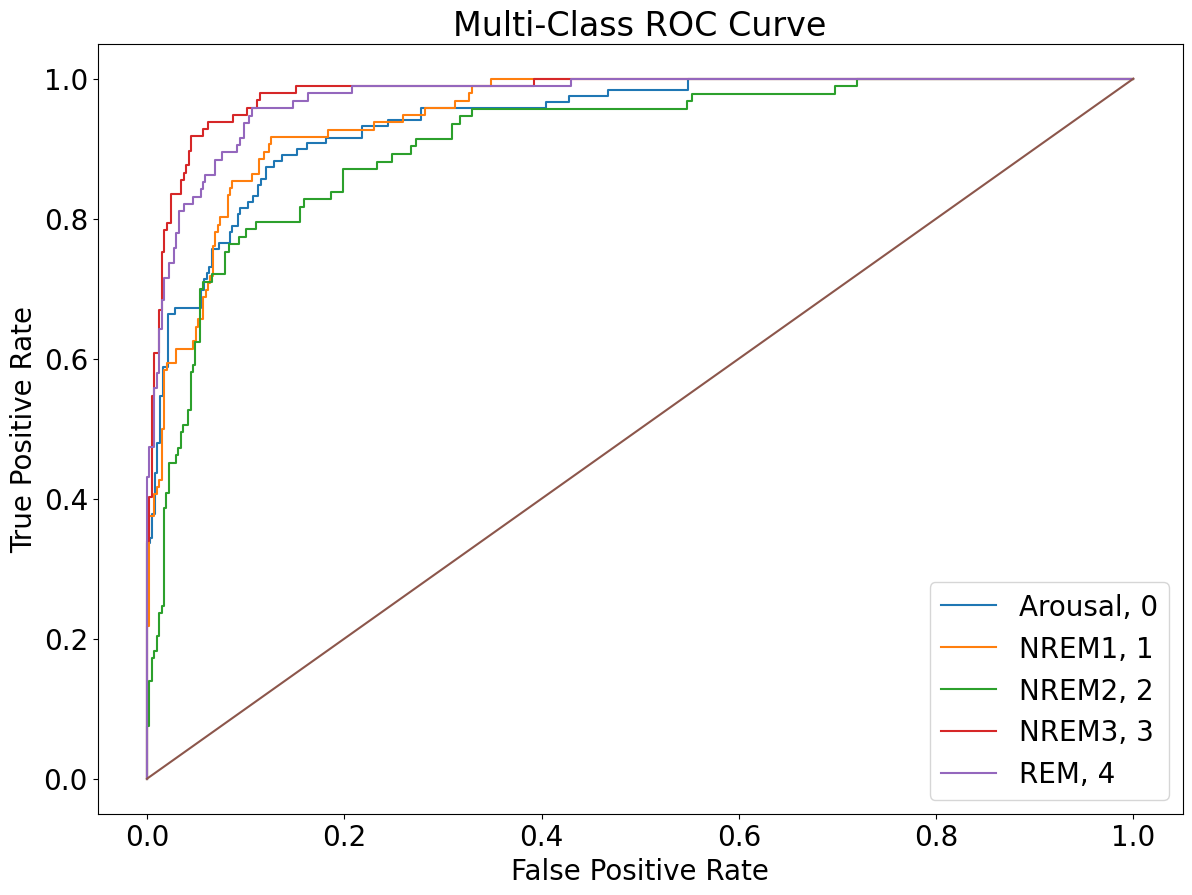

In [15]:
fpr = {}
tpr = {}
roc_auc = {}

plt.figure(figsize=(14,10))
for i in range(5):
    fpr[i], tpr[i], _ = metrics.roc_curve(test_labels_one_hot.iloc[:, i], test_pred.iloc[:, i])
    roc_auc[i] = metrics.auc(fpr[i], tpr[i])
    plt.plot(fpr[i], tpr[i], label = stage_dict[i] + ', ' + str(i))

plt.plot([0, 1], [0, 1])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend()
plt.show()

fpr["micro"], tpr["micro"], _ = metrics.roc_curve(test_labels_one_hot.values.ravel(), test_pred.values.ravel())
roc_auc_agg = metrics.auc(fpr["micro"], tpr["micro"])

In [16]:
y_true = []
y_pred = []
for i in range(test_pred.shape[0]):
    if test_predict.iloc[i]==0: y_pred.append(1)
    else: y_pred.append(-1)
    if test_labels[i]==0: y_true.append(1)
    else: y_true.append(-1)
mcc = metrics.matthews_corrcoef(y_true, y_pred)

In [17]:
print(roc_auc_agg, mcc)

0.953759 0.6831298674295517


In [18]:
from sklearn.metrics import average_precision_score

# your existing mocktest split — same random shuffle as everything else in the notebook
y_true_arousal = (np.array([np.where(l==1)[0][0] for l in mocktest_labels]) == 0).astype(int)
p_arousal = model.predict(mocktest_data)[:, 0]

auprc = average_precision_score(y_true_arousal, p_arousal)
baseline = y_true_arousal.mean()

print(f'AUPRC: {auprc:.4f}')
print(f'Random-guess floor (arousal prevalence): {baseline:.4f}')
print(f'For comparison — actual PhysioNet 2018 Challenge winner: 0.54, on real (unbalanced,')
print(f'continuous, patient-disjoint) data. This number is not directly comparable to that one.')

AUPRC: 0.8653
Random-guess floor (arousal prevalence): 0.2380
For comparison — actual PhysioNet 2018 Challenge winner: 0.54, on real (unbalanced,
continuous, patient-disjoint) data. This number is not directly comparable to that one.


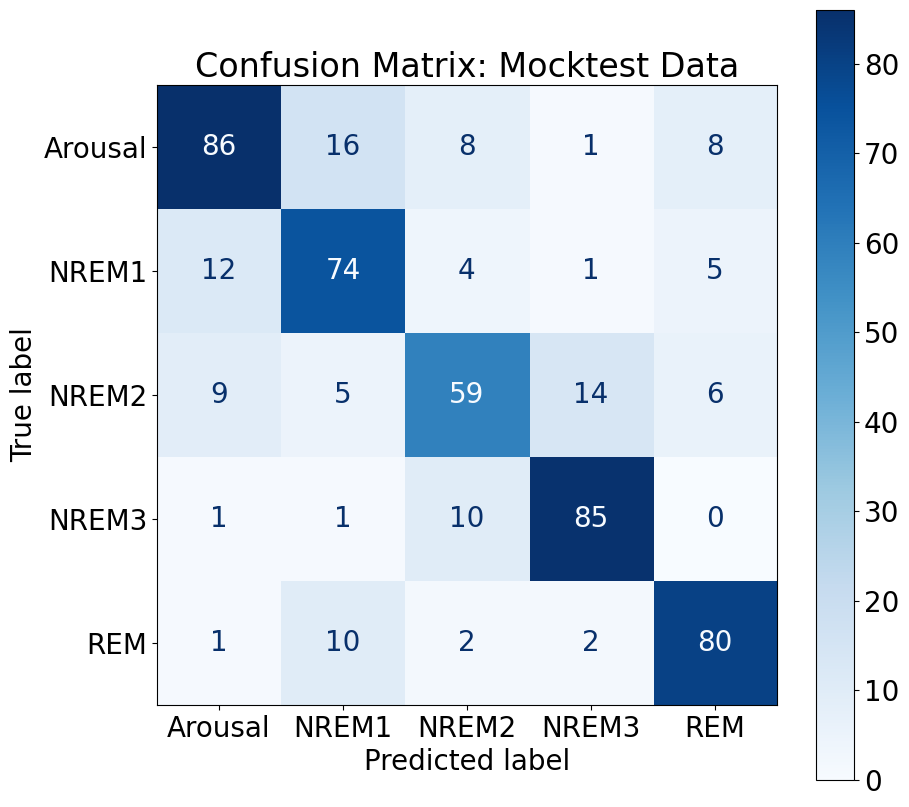

In [23]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get predictions and true labels for the mocktest set
y_pred_mock = model.predict(mocktest_data).argmax(axis=1)
y_true_mock = mocktest_labels.argmax(axis=1)

# Create the confusion matrix
cm = confusion_matrix(y_true_mock, y_pred_mock)

# Plot the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[stage_dict[i] for i in range(5)])
disp.plot(cmap=plt.cm.Blues, ax=ax, xticks_rotation='horizontal')
plt.title('Confusion Matrix: Mocktest Data')
plt.show()